# Packages

In [1]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install("edgeR")
BiocManager::install("AnnotationDbi")
BiocManager::install("org.Mm.eg.db")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.22), R 4.3.2 (2023-10-31)

Installing package(s) 'BiocVersion', 'edgeR'

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'Biobase', 'BiocGenerics', 'BiocParallel', 'bslib',
  'DelayedArray', 'DESeq2', 'dplyr', 'GenomeInfoDb', 'GenomeInfoDbData',
  'GenomicRanges', 'htmlwidgets', 'IRanges', 'limma', 'MatrixGenerics', 'nlme',
  'RcppArmadillo', 'S4Arrays', 'S4Vectors', 'shiny', 'stringi',
  'SummarizedExperiment', 'tinytex', 'XVector', 'zlibbioc'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-p

In [2]:
install.packages("dplyr")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
library("edgeR")
library("dplyr")
library("AnnotationDbi")
library("org.Mm.eg.db")

NameError: name 'library' is not defined

# DEG (differentially expressed genes) using EdgeR

In [6]:
filepath = "/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_rnaseq_sample_list.tsv"
sample_info <- read.table(filepath, header=TRUE, row.names=1)
head(sample_info)

,genotype,tissue,treatment,time_point,replicate
,<chr>,<chr>,<chr>,<int>,<chr>
A111,UCR,VS,control,1,r1
A211,UCR,VS,control,1,r2
A311,UCR,VS,control,1,r3
A411,UCR,VS,control,1,r4
A112,Epicselect,VS,control,1,r1
A212,Epicselect,VS,control,1,r2


In [4]:
# Load raw count data
filepath = "/scratch/sah2p/datasets/2023_11_05_MohitCowPea/Cowpea_quant_isr_counts.tsv"
raw_counts <- read.table(filepath, header = TRUE, row.names = 1)
head(raw_counts)

,A111,A211,A311,A411,A112,A212,A312,A412,A121,A221,⋯,C312,C412,C121,C221,C321,C421,C122,C222,C322,C422
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
VigunL059001.v1.2,0,0,0,3,0,0,0,0,0,0,⋯,0,0,0,0,0,1,0,0,0,0
VigunL000101.v1.2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
VigunL000300.v1.2,0,0,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,32,0,0,0,0
VigunL000202.v1.2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,2,0,0,2,0,0,0,0
VigunL001800.v1.2,1432,2186,1558,2328,873,2594,1102,943,2764,4117,⋯,426,367,1077,796,1249,743,616,1026,877,839
VigunL059106.v1.2,0,0,0,0,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0


In [ ]:
# selecting required coloums only, IF NEEDED

# raw_count_selected <- raw_counts[,c("N4_50000_S1","N4_50000_S2","N4_50000_S3","N4_50000_S4","T4_50000_S6","T4_50000_S7","T4_50000_S8")]
# head(raw_count_selected)

In [8]:
group <- factor(c(sample_info$treatment))
group

[1] control control control control control control control control WL     
[10] WL      WL      WL      WL      WL      WL      WL      control control
[19] control control control control control control WL      WL      WL     
[28] WL      WL      WL      WL      WL      control control control control
[37] control control control control WL      WL      WL      WL      WL     
[46] WL      WL      WL     
Levels: control WL

In [29]:
# create groups for the samples
# here we have 2 groups for this analysis (original dataset had 3, we selected 2)

group <- factor(c('1','1','1','1','2','2','2'))

# for this dataset we had 3 groups, so below 2 lines are if we are using these 3 groups
# group <- factor(c('N4_1000','N4_1000','N4_50000','N4_50000','N4_50000','N4_50000','T4_50000','T4_50000','T4_50000','N4_1000'))
# group <- factor(c('3','3','1','1','1','1','2','2','2','3'))

str(group)

 Factor w/ 2 levels "1","2": 1 1 1 1 2 2 2


In [9]:
# dgeGlm - Digital Gene Expression Generalized Linear Model

# The DGEList object holds the dataset to be analysed by edgeR and the subsequent calculations performed on the dataset.
# Specifically it contains: counts. numeric matrix containing the read counts.

dgeGlm <- DGEList(counts=raw_counts, group =group)
head(dgeGlm)
str(dgeGlm)

An object of class "DGEList"
$counts
                  A111 A211 A311 A411 A112 A212 A312 A412 A121 A221 A321 A421
VigunL059001.v1.2    0    0    0    3    0    0    0    0    0    0    1    0
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2    0    0    0    0    0    0    1    0    0    0    0    0
VigunL000202.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL001800.v1.2 1432 2186 1558 2328  873 2594 1102  943 2764 4117  919  836
VigunL059106.v1.2    0    0    0    0    0    0    0    0    0    1    0    0
                  A122 A222 A322 A422 B111 B211 B311 B411 B112 B212 B312 B412
VigunL059001.v1.2    0    0    0    0    2    0    0    0    0    0    0    0
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2    0    0   18    0    0    0    0    0    0    0    0    2
VigunL000202.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL001800.v1.2  937 1001  725  976 1060  893  893  713  675  534  174  661
VigunL059106.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
                  B121 B221 B321 B421 B122 B222 B322 B422 C111 C211 C311 C411
VigunL059001.v1.2    0    1    0    1    0    0    0    0    0    0    1    2
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2   71    0    0    0    0    8    4    0    0    0    0    0
VigunL000202.v1.2    6    0    0    0    0    0    0    0    2    0    0    0
VigunL001800.v1.2 1220  919  982  954  902  627 1117  740  488  610  819  595
VigunL059106.v1.2    0    0    0    0    0    0    0    2    0    0    0    0
                  C112 C212 C312 C412 C121 C221 C321 C421 C122 C222 C322 C422
VigunL059001.v1.2    0    2    0    0    0    0    0    1    0    0    0    0
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2    0   46    0    0    0    0    0   32    0    0    0    0
VigunL000202.v1.2    0    0    0    0    2    0    0    2    0    0    0    0
VigunL001800.v1.2 1003  448  426  367 1077  796 1249  743  616 1026  877  839
VigunL059106.v1.2    0    0    0    0    0    0    0    0    0    0    0    0

$samples
       group lib.size norm.factors
A111 control 90056923            1
A211 control 95609058            1
A311 control 89444183            1
A411 control 81752164            1
A112 control 63822480            1
43 more rows ...

Formal class 'DGEList' [package "edgeR"] with 1 slot
  ..@ .Data:List of 2
  .. ..$ : int [1:26339, 1:48] 0 0 0 0 1432 0 817 0 50 30 ...
  .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. ..$ : chr [1:26339] "VigunL059001.v1.2" "VigunL000101.v1.2" "VigunL000300.v1.2" "VigunL000202.v1.2" ...
  .. .. .. ..$ : chr [1:48] "A111" "A211" "A311" "A411" ...
  .. ..$ :'data.frame':	48 obs. of  3 variables:
  .. .. ..$ group       : Factor w/ 2 levels "control","WL": 1 1 1 1 1 1 1 1 2 2 ...
  .. .. ..$ lib.size    : num [1:48] 90056923 95609058 89444183 81752164 63822480 ...
  .. .. ..$ norm.factors: num [1:48] 1 1 1 1 1 1 1 1 1 1 ...
  ..$ names: chr [1:2] "counts" "samples"


In [10]:
dgeGlm_normalized <- calcNormFactors(dgeGlm, method = "TMM") # method="TMM" is the weighted trimmed mean of M-values
head(dgeGlm_normalized)

An object of class "DGEList"
$counts
                  A111 A211 A311 A411 A112 A212 A312 A412 A121 A221 A321 A421
VigunL059001.v1.2    0    0    0    3    0    0    0    0    0    0    1    0
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2    0    0    0    0    0    0    1    0    0    0    0    0
VigunL000202.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL001800.v1.2 1432 2186 1558 2328  873 2594 1102  943 2764 4117  919  836
VigunL059106.v1.2    0    0    0    0    0    0    0    0    0    1    0    0
                  A122 A222 A322 A422 B111 B211 B311 B411 B112 B212 B312 B412
VigunL059001.v1.2    0    0    0    0    2    0    0    0    0    0    0    0
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2    0    0   18    0    0    0    0    0    0    0    0    2
VigunL000202.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL001800.v1.2  937 1001  725  976 1060  893  893  713  675  534  174  661
VigunL059106.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
                  B121 B221 B321 B421 B122 B222 B322 B422 C111 C211 C311 C411
VigunL059001.v1.2    0    1    0    1    0    0    0    0    0    0    1    2
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2   71    0    0    0    0    8    4    0    0    0    0    0
VigunL000202.v1.2    6    0    0    0    0    0    0    0    2    0    0    0
VigunL001800.v1.2 1220  919  982  954  902  627 1117  740  488  610  819  595
VigunL059106.v1.2    0    0    0    0    0    0    0    2    0    0    0    0
                  C112 C212 C312 C412 C121 C221 C321 C421 C122 C222 C322 C422
VigunL059001.v1.2    0    2    0    0    0    0    0    1    0    0    0    0
VigunL000101.v1.2    0    0    0    0    0    0    0    0    0    0    0    0
VigunL000300.v1.2    0   46    0    0    0    0    0   32    0    0    0    0
VigunL000202.v1.2    0    0    0    0    2    0    0    2    0    0    0    0
VigunL001800.v1.2 1003  448  426  367 1077  796 1249  743  616 1026  877  839
VigunL059106.v1.2    0    0    0    0    0    0    0    0    0    0    0    0

$samples
       group lib.size norm.factors
A111 control 90056923    0.9972506
A211 control 95609058    1.0195727
A311 control 89444183    1.0869906
A411 control 81752164    1.1343832
A112 control 63822480    1.1340392
43 more rows ...

In [11]:
# I do not understand that clearly yet, so NEED TO REVISIT

# calculates the CPM (counts per million) values, checks if they are greater than 2,
# and then checks if at least 4 samples meet this condition for each gene

keep <- rowSums(cpm(dgeGlm_normalized)>2) >= 4
str(keep)
head(keep)

dgeGlm_normalized <- dgeGlm_normalized[keep,]
head(dgeGlm_normalized)
write.csv(dgeGlm_normalized$counts, "Selected_Samples_Group")


 Named logi [1:26339] FALSE FALSE FALSE FALSE TRUE FALSE ...
 - attr(*, "names")= chr [1:26339] "VigunL059001.v1.2" "VigunL000101.v1.2" "VigunL000300.v1.2" "VigunL000202.v1.2" ...


VigunL059001.v1.2 VigunL000101.v1.2 VigunL000300.v1.2 VigunL000202.v1.2 
            FALSE             FALSE             FALSE             FALSE 
VigunL001800.v1.2 VigunL059106.v1.2 
             TRUE             FALSE

An object of class "DGEList"
$counts
                  A111 A211 A311 A411 A112 A212 A312 A412 A121 A221 A321 A421
VigunL001800.v1.2 1432 2186 1558 2328  873 2594 1102  943 2764 4117  919  836
VigunL059406.v1.2  817  220  781  301  367 1008  950  698 1320  960  577  680
VigunL003500.v1.2   36   13  291  218  121   43   51   51    8   10   83   55
VigunL005900.v1.2 3572 4329 4224 5746 2960 2685 4249 2332 7039 3546 2850 3418
VigunL007201.v1.2   31  142   92  120  456  260   84   89  156   80  259 2173
VigunL007501.v1.2   58   78   29   44  214  311   69   29   65   53  305  665
                  A122 A222 A322 A422 B111 B211 B311 B411 B112 B212 B312 B412
VigunL001800.v1.2  937 1001  725  976 1060  893  893  713  675  534  174  661
VigunL059406.v1.2  756 1010  912  883  483  524  512  347  654  347  438  607
VigunL003500.v1.2   65   43   47   28  281  186   68  129  165  117   60  142
VigunL005900.v1.2 2483 3696 3085 3808 3483 4737 3057 2878 2531 2560 1899 2977
VigunL007201.v1.2  518  126 1898  122   21   17   10   32   12   24  486   12
VigunL007501.v1.2  567   39 2117  106    4    3    3    5    3    4   24    4
                  B121 B221 B321 B421 B122 B222 B322 B422 C111 C211 C311 C411
VigunL001800.v1.2 1220  919  982  954  902  627 1117  740  488  610  819  595
VigunL059406.v1.2  650  730  908  757  679  480  771  816  457  573  602  366
VigunL003500.v1.2   72   39   27   22   58   75   52   55  116   73   73   53
VigunL005900.v1.2 4219 3815 4105 3544 2421 1456 2243 2689 3264 3177 3194 1905
VigunL007201.v1.2   47   55   75 1203   24 1626   71   28   53   34  228   62
VigunL007501.v1.2   11   33   29  660   27  807   10    2   37    4  260   38
                  C112 C212 C312 C412 C121 C221 C321 C421 C122 C222 C322 C422
VigunL001800.v1.2 1003  448  426  367 1077  796 1249  743  616 1026  877  839
VigunL059406.v1.2  684  530  576  414 1129  792  769  911  614  706  980  874
VigunL003500.v1.2   14   46  142   66   38   27    9   13   28   88   75   14
VigunL005900.v1.2 2236 1992 1707 2085 3552 2720 3255 3117 1094 1646 1913 1097
VigunL007201.v1.2  181  943  151   21 1685 1187  165   52   32 1608  181   52
VigunL007501.v1.2   30  198   35    9  448  454  194   35   20  425  189   23

$samples
       group lib.size norm.factors
A111 control 90056923    0.9972506
A211 control 95609058    1.0195727
A311 control 89444183    1.0869906
A411 control 81752164    1.1343832
A112 control 63822480    1.1340392
43 more rows ...

In [12]:
# model.matrix creates a design (or model) matrix, e.g., by expanding factors to a set of dummy variables 
design <- model.matrix(~group)
print(design)

   (Intercept) groupWL
1            1       0
2            1       0
3            1       0
4            1       0
5            1       0
6            1       0
7            1       0
8            1       0
9            1       1
10           1       1
11           1       1
12           1       1
13           1       1
14           1       1
15           1       1
16           1       1
17           1       0
18           1       0
19           1       0
20           1       0
21           1       0
22           1       0
23           1       0
24           1       0
25           1       1
26           1       1
27           1       1
28           1       1
29           1       1
30           1       1
31           1       1
32           1       1
33           1       0
34           1       0
35           1       0
36           1       0
37           1       0
38           1       0
39           1       0
40           1       0
41           1       1
42           1       1
43         

In [13]:
dgeGlm_normalized_ComDisp <- estimateGLMCommonDisp(dgeGlm_normalized, design, verbose = TRUE)

# It estimates a common negative binomial dispersion parameter for a DGE dataset with a general experimental design.
# The function uses the design matrix temporarily to estimate the dispersion.

Disp = 0.40572 , BCV = 0.637 


In [14]:
dgeGlm_normalized_TrendDisp <- estimateGLMTrendedDisp (dgeGlm_normalized_ComDisp, design)
# print(dgeGlm_normalized_TrendDisp)

# Trended dispersion is the mean dispersion across all genes with similar abundance.
# It's the fitted value of the mean-dispersion trend.

In [15]:
dgeGlm_normalized_TagDisp <- estimateGLMTagwiseDisp (dgeGlm_normalized_TrendDisp, design)
# print(dgeGlm_normalized_TagDisp)

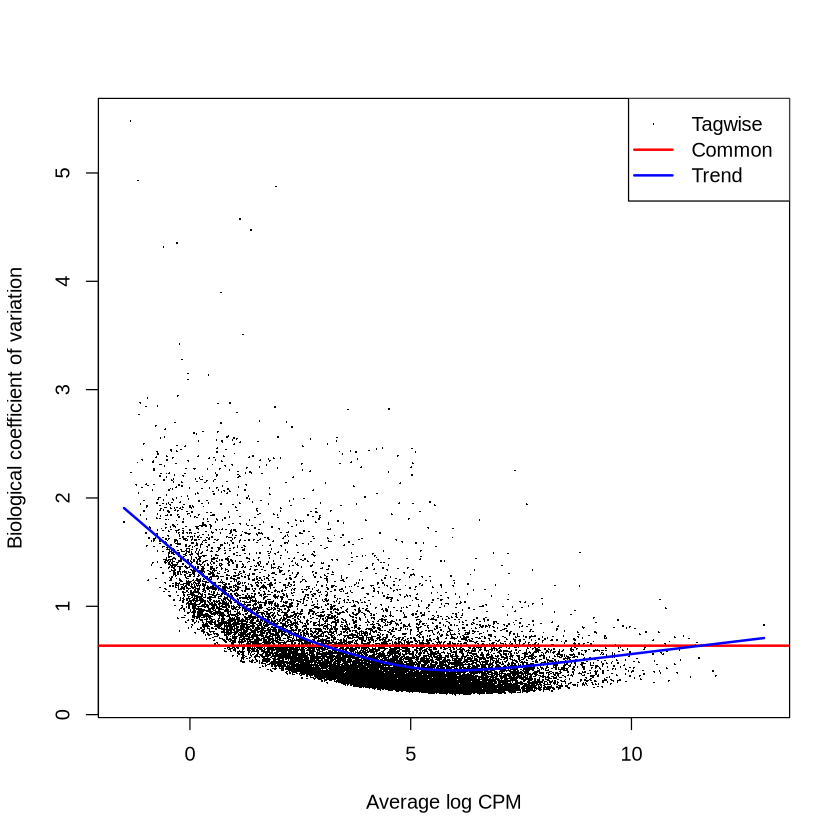

In [16]:
plotBCV(dgeGlm_normalized_TagDisp)

In [17]:
fit <- glmFit(dgeGlm_normalized_TagDisp, design)

In [18]:
colnames(coef(fit))
lrt <- glmLRT(fit, coef=2)
# str(lrt)
print(lrt)

[1] "(Intercept)" "groupWL"

An object of class "DGELRT"
$coefficients
                  (Intercept)    groupWL
VigunL001800.v1.2   -11.27787  0.0449124
VigunL059406.v1.2   -11.78053  0.2886460
VigunL003500.v1.2   -13.39461 -0.9733605
VigunL005900.v1.2   -10.06375 -0.1439383
VigunL007201.v1.2   -13.06105  1.2753594
19110 more rows ...

$fitted.values
                       A111      A211      A311      A411      A112      A212
VigunL001800.v1.2 1135.9201 1232.9447 1229.7144 1172.9660  915.4362 1290.5989
VigunL059406.v1.2  687.0847  745.7721  743.8182  709.4927  553.7205  780.6454
VigunL003500.v1.2  136.6627  148.3358  147.9471  141.1197  110.1363  155.2722
VigunL005900.v1.2 3825.3760 4152.1205 4141.2421 3950.1336 3082.8646 4346.2795
VigunL007201.v1.2  190.8307  207.1305  206.5878  197.0543  153.7902  216.8162
                       A312      A412      A121       A221       A321
VigunL001800.v1.2 1387.1743 1132.0983 1514.0071 1696.69543  886.98347
VigunL059406.v1.2  839.0610  684.7730 1168.5931 1309.60194  684.6221

In [19]:
ttGlm <- topTags(lrt, n = Inf)
str(ttGlm)
# class(ttGlm)

Formal class 'TopTags' [package "edgeR"] with 1 slot
  ..@ .Data:List of 4
  .. ..$ :'data.frame':	19115 obs. of  5 variables:
  .. .. ..$ logFC : num [1:19115] 13.04 9.02 13.21 -3.38 -4.89 ...
  .. .. ..$ logCPM: num [1:19115] 2.78 11.31 4.44 6.69 9.99 ...
  .. .. ..$ LR    : num [1:19115] 493 475 357 284 250 ...
  .. .. ..$ PValue: num [1:19115] 3.60e-109 3.19e-105 1.42e-79 1.11e-63 2.54e-56 ...
  .. .. ..$ FDR   : num [1:19115] 6.87e-105 3.05e-101 9.06e-76 5.31e-60 9.73e-53 ...
  .. ..$ : chr "BH"
  .. ..$ : chr "groupWL"
  .. ..$ : chr "glm"
  ..$ names: chr [1:4] "table" "adjust.method" "comparison" "test"


       groupWL
Down      4226
NotSig   10978
Up        3911

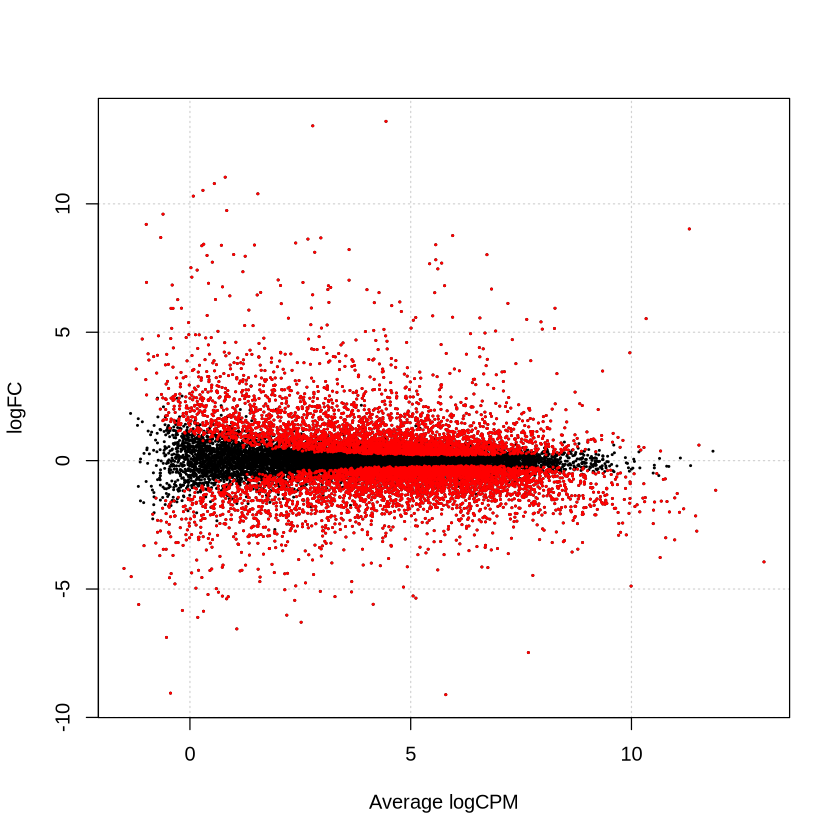

In [20]:
summary(dgeGlm_normalized_Tests <- decideTestsDGE(lrt, p = 0.05, adjust = "fdr"))
tagsGlm <- rownames(dgeGlm_normalized_TagDisp)[as.logical(dgeGlm_normalized_Tests)]

plotSmear(lrt, de.tags = tagsGlm)

In [ ]:
defg_1vs2 <- ttGlm$table[ttGlm$table$FDR < 0.1,]
str(defg_1vs2)
write.csv(defg_1vs2, /scratch/sah2p/datasets/2023_11_05_MohitCowPea/output/DEG_EdgeR_1_vs_2.csv")

'data.frame':	1845 obs. of  5 variables:
 $ logFC : num  -1.755 -1.135 -1.186 1.105 0.825 ...
 $ logCPM: num  6.96 8.53 9.69 6.97 8.27 ...
 $ LR    : num  177 135.7 121.2 98.9 90.5 ...
 $ PValue: num  2.17e-40 2.31e-31 3.46e-28 2.63e-23 1.89e-21 ...
 $ FDR   : num  2.86e-36 1.52e-27 1.52e-24 8.69e-20 4.98e-18 ...


# Pathways

## Read Tables

In [ ]:
# kegg file has the path ways but ensembl_gene_id is not available
kegg_mmu <- read.table(file = "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/kegg_bm_mmu/kegg_mmu.txt", header = TRUE)
tail(kegg_mmu)

,mmu_name,category,region,external_gene_name,pathway_name,pathway
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
204856,mmu:15130,CDS,7 E3; 7 54.85 cM,Hbb2,mmu05143,African trypanosomiasis - Mus musculus (house mouse)
204857,mmu:15130,CDS,7 E3; 7 54.85 cM,Hbb2,mmu05144,Malaria - Mus musculus (house mouse)
204858,mmu:15130,CDS,7 E3; 7 54.85 cM,Hbbt2,mmu05143,African trypanosomiasis - Mus musculus (house mouse)
204859,mmu:15130,CDS,7 E3; 7 54.85 cM,Hbbt2,mmu05144,Malaria - Mus musculus (house mouse)
204860,mmu:15130,CDS,7 E3; 7 54.85 cM,beta2,mmu05143,African trypanosomiasis - Mus musculus (house mouse)
204861,mmu:15130,CDS,7 E3; 7 54.85 cM,beta2,mmu05144,Malaria - Mus musculus (house mouse)


In [ ]:
# to get the ensembl_gene_id associate4d with the external_gene_name we are using this file
bm_mmu <- read.table(file = "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/kegg_bm_mmu/bm_mmu.txt", header = TRUE)
tail(bm_mmu)

,ensembl_gene_id,external_gene_name,chromosome_name,start_position,end_position,strand,gene_biotype,description
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
56936,ENSMUSG00000039715,Dync2i2,2,29921558,29938893,-1,protein_coding,dynein 2 intermediate chain 2 [Source:MGI Symbol;Acc:MGI:1919070]
56937,ENSMUSG00000054766,Set,2,29947390,29962589,1,protein_coding,SET nuclear oncogene [Source:MGI Symbol;Acc:MGI:1860267]
56938,ENSMUSG00000026785,Pkn3,2,29967696,29981034,1,protein_coding,protein kinase N3 [Source:MGI Symbol;Acc:MGI:2388285]
56939,ENSMUSG00000015335,Zdhhc12,2,29980956,29983660,-1,protein_coding,"zinc finger, DHHC domain containing 12 [Source:MGI Symbol;Acc:MGI:1913470]"
56940,ENSMUSG00000039686,Zer1,2,29987295,30014597,-1,protein_coding,"zyg-11 related, cell cycle regulator [Source:MGI Symbol;Acc:MGI:2442511]"
56941,ENSMUSG00000100747,1700084E18Rik,2,30126807,30128235,-1,lncRNA,RIKEN cDNA 1700084E18 gene [Source:MGI Symbol;Acc:MGI:1914600]


In [ ]:
defg_1vs2 <- read.csv(file = "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/results/DEG_EdgeR_1_vs_2.csv", header = TRUE)
colnames(defg_1vs2)[1] <- "ensembl_gene_id"
tail(defg_1vs2)

,ensembl_gene_id,logFC,logCPM,LR,PValue,FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1840,ENSMUSG00000029516,-0.7844909,2.847223,6.063522,0.01380022,0.09898656
1841,ENSMUSG00000024319,-0.3468158,4.929401,6.060156,0.01382655,0.09912154
1842,ENSMUSG00000095524,0.6428896,2.865234,6.052903,0.01388346,0.09944404
1843,ENSMUSG00000038346,-0.3169545,5.372781,6.052503,0.01388660,0.09944404
1844,ENSMUSG00000038271,-0.4489841,4.466885,6.047582,0.01392535,0.09966747
1845,ENSMUSG00000050390,1.0238452,2.448871,6.043419,0.01395823,0.09984862


## Merge

In [ ]:
# merged to use it with the results
bm_mmu_gene_id_name_only <- bm_mmu[,c("ensembl_gene_id","external_gene_name")]
defg_1vs2_external_gene_name <-merge(defg_1vs2, bm_mmu_gene_id_name_only, by = "ensembl_gene_id")
defg_1vs2_external_gene_name <- defg_1vs2_external_gene_name[,c("external_gene_name","ensembl_gene_id","logFC","logCPM","PValue","FDR")]
tail(defg_1vs2_external_gene_name)
write.csv(defg_1vs2_external_gene_name, "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/results/defg_1vs2_external_gene_name.csv")

,external_gene_name,ensembl_gene_id,logFC,logCPM,PValue,FDR
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1822,Aldoa-ps4,ENSMUSG00000111336,-0.7329402,2.946196,7.478161e-03,6.610634e-02
1823,Gm47050,ENSMUSG00000111546,2.0345687,2.883186,9.894778e-09,1.483992e-06
1824,Gm4977,ENSMUSG00000111613,0.2974393,6.420831,6.752465e-03,6.180238e-02
1825,Gm8543,ENSMUSG00000111684,0.5391290,6.010039,2.985342e-05,1.076517e-03
1826,Gm48720,ENSMUSG00000111690,-0.4512521,5.086407,2.400589e-03,3.020303e-02
1827,Gm6477,ENSMUSG00000111877,0.3471048,5.764690,1.879018e-03,2.546127e-02


In [ ]:
# # merged to use it with the results
# kegg_bm_mmu <-merge(kegg_mmu, bm_mmu, by = "external_gene_name")
# tail(kegg_bm_mmu)

In [ ]:
# defg_1vs2_kegg_bm_mmu <-merge(defg_1vs2, kegg_bm_mmu, by = "ensembl_gene_id")
# tail(defg_1vs2_kegg_bm_mmu)
# write.csv(defg_1vs2_kegg_bm_mmu, "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/results/defg_1vs2_kegg_bm_mmu.csv")

In [ ]:
# defg_1vs2_kegg_bm_mmu %>% group_by(ensembl_gene_id) %>% summarise(Count = n())

In [ ]:
# UpGenes <- defg_1vs2_kegg_bm_mmu[ defg_1vs2_kegg_bm_mmu$logFC > 0, ]
# DownGenes <- defg_1vs2_kegg_bm_mmu[ defg_1vs2_kegg_bm_mmu$logFC < 0,]

# write.csv(UpGenes, "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/results/UpGenes.csv")
# write.csv(DownGenes, "/scratch/ag5cg/2023_08_28_Emma_Teixeiro_Influenza/results/DownGenes.csv")
